In [22]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as npr
import pandas as pd
import seaborn as sns

In [2]:
#Load Data
df=pd.read_excel('Bursa Malaysia Listing 3.0.xls', sheet_name='Screening', engine='xlrd')
df.head()

,Company Name,Total Revenue 2016,Total Revenue 2017,Total Revenue 2018,Total Revenue 2019,Total Revenue 2020,Total Revenue 2021,Net Income 2016,Net Income 2017,Net Income 2018,...,Accounts Receivable 2019,Accounts Receivable 2020,Accounts Receivable 2021,PPE 2016,PPE 2017,PPE 2018,PPE 2019,PPE 2020,PPE 2021,Primary Sector
0,3REN Berhad (KLSE:3REN),-,-,-,-,15.7,17.8,-,-,-,...,-,4.22,4.73,-,-,-,-,0.838,2.19,Information Technology
1,7-Eleven Malaysia Holdings Berhad (KLSE:SEM),469,537.8,536.1,576.6,631.8,674.1,11.6,12.3,12.4,...,0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples
2,99 Speed Mart Retail Holdings Berhad (KLSE:99S...,-,-,-,-,1702.3,1880.9,-,-,-,...,-,4.66,4.15,-,-,-,-,286.2,271.6,Consumer Staples
3,A-Rank Berhad (KLSE:ARANK),101.5,123.5,119.6,118.2,109.7,161.3,3.87,3.55,3.22,...,10.3,13.2,16.6,12.3,14.7,13.3,12.6,12.1,12.9,Materials
4,ABF Malaysia Bond Index Fund (KLSE:ABFMY1),-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,Financials


# Data Cleaning & Formating

In [3]:
#Standardize company name format
df['Company Name'] = df['Company Name'].str.replace(r"\s*\(.*?\)", "", regex=True)
df.head()

,Company Name,Total Revenue 2016,Total Revenue 2017,Total Revenue 2018,Total Revenue 2019,Total Revenue 2020,Total Revenue 2021,Net Income 2016,Net Income 2017,Net Income 2018,...,Accounts Receivable 2019,Accounts Receivable 2020,Accounts Receivable 2021,PPE 2016,PPE 2017,PPE 2018,PPE 2019,PPE 2020,PPE 2021,Primary Sector
0,3REN Berhad,-,-,-,-,15.7,17.8,-,-,-,...,-,4.22,4.73,-,-,-,-,0.838,2.19,Information Technology
1,7-Eleven Malaysia Holdings Berhad,469,537.8,536.1,576.6,631.8,674.1,11.6,12.3,12.4,...,0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples
2,99 Speed Mart Retail Holdings Berhad,-,-,-,-,1702.3,1880.9,-,-,-,...,-,4.66,4.15,-,-,-,-,286.2,271.6,Consumer Staples
3,A-Rank Berhad,101.5,123.5,119.6,118.2,109.7,161.3,3.87,3.55,3.22,...,10.3,13.2,16.6,12.3,14.7,13.3,12.6,12.1,12.9,Materials
4,ABF Malaysia Bond Index Fund,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,Financials


In [4]:
#Identify null cases
df.apply(lambda x: sum(x.isnull()), axis=0)

Company Name                1
Total Revenue 2016          2
Total Revenue 2017          2
Total Revenue 2018          2
Total Revenue 2019          2
Total Revenue 2020          2
Total Revenue 2021          2
Net Income 2016             2
Net Income 2017             2
Net Income 2018             2
Net Income 2019             2
Net Income 2020             2
Net Income 2021             2
Cash from Ops 2016          2
Cash from Ops 2017          2
Cash from Ops 2018          2
Cash from Ops 2019          2
Cash from Ops 2020          2
Cash from Ops 2021          2
Total Assets 2016           2
Total Assets 2017           2
Total Assets 2018           2
Total Assets 2019           2
Total Assets 2020           2
Total Assets 2021           2
Accounts Receivable 2016    2
Accounts Receivable 2017    2
Accounts Receivable 2018    2
Accounts Receivable 2019    2
Accounts Receivable 2020    2
Accounts Receivable 2021    2
PPE 2016                    2
PPE 2017                    2
PPE 2018  

In [5]:
#Drop row with null and missing value
df1 = df.copy()
df1.dropna(axis=0, inplace=True)
df1 = df1[~df.iloc[:, 2:-1].apply(lambda x: x.astype(str).str.contains('-')).any(axis=1)]

C:\Users\hp\AppData\Local\Temp\ipykernel_28456\3989605822.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df1[~df.iloc[:, 2:-1].apply(lambda x: x.astype(str).str.contains('-')).any(axis=1)]


In [6]:
#Check
df1.apply(lambda x: sum(x.isnull()), axis=0)

Company Name                0
Total Revenue 2016          0
Total Revenue 2017          0
Total Revenue 2018          0
Total Revenue 2019          0
Total Revenue 2020          0
Total Revenue 2021          0
Net Income 2016             0
Net Income 2017             0
Net Income 2018             0
Net Income 2019             0
Net Income 2020             0
Net Income 2021             0
Cash from Ops 2016          0
Cash from Ops 2017          0
Cash from Ops 2018          0
Cash from Ops 2019          0
Cash from Ops 2020          0
Cash from Ops 2021          0
Total Assets 2016           0
Total Assets 2017           0
Total Assets 2018           0
Total Assets 2019           0
Total Assets 2020           0
Total Assets 2021           0
Accounts Receivable 2016    0
Accounts Receivable 2017    0
Accounts Receivable 2018    0
Accounts Receivable 2019    0
Accounts Receivable 2020    0
Accounts Receivable 2021    0
PPE 2016                    0
PPE 2017                    0
PPE 2018  

In [7]:
#Standardize column name
df1.columns = (
    df1.columns
    .str.replace('Net Income ', 'NI_')
    .str.replace('Cash from Ops ', 'OCF_')
    .str.replace('Accounts Receivable ', 'AR_')
    .str.replace('Total Assets ', 'TA_')
    .str.replace('Total Revenue ', 'REV_')
    .str.replace('PPE ', 'PPE_')
)

In [8]:
df1.head()

,Company Name,REV_2016,REV_2017,REV_2018,REV_2019,REV_2020,REV_2021,NI_2016,NI_2017,NI_2018,...,AR_2019,AR_2020,AR_2021,PPE_2016,PPE_2017,PPE_2018,PPE_2019,PPE_2020,PPE_2021,Primary Sector
1,7-Eleven Malaysia Holdings Berhad,469,537.8,536.1,576.6,631.8,674.1,11.6,12.3,12.4,...,0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples
12,Advancecon Holdings Berhad,52.3,65.4,66,73.8,62.3,65,5.9,4.54,2.57,...,40.1,43.7,35.6,30.4,45.3,46,43.7,40.9,35.3,Industrials
16,Aeon Co. Bhd.,900.6,1014,1052.7,1108.4,1008.1,871.3,17.8,25.8,25.4,...,11.4,20,22.5,771.7,861.7,894.6,1323.5,1258.2,1106.3,Consumer Staples
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.1,46.9,14.4,...,10.5,10.1,11.9,18.5,21.3,18.6,38.5,72.3,98.5,Consumer Staples
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,...,22.1,19.1,17.9,40.8,42.8,38,36.4,38.2,34.3,Industrials


In [9]:
col_dtype = ['REV_2016', 'REV_2017', 'REV_2018', 'REV_2019',
       'REV_2020', 'REV_2021', 'NI_2016', 'NI_2017', 'NI_2018', 'NI_2019',
       'NI_2020', 'NI_2021', 'OCF_2016', 'OCF_2017', 'OCF_2018', 'OCF_2019',
       'OCF_2020', 'OCF_2021', 'TA_2016', 'TA_2017', 'TA_2018', 'TA_2019',
       'TA_2020', 'TA_2021', 'AR_2016', 'AR_2017', 'AR_2018', 'AR_2019',
       'AR_2020', 'AR_2021', 'PPE_2016', 'PPE_2017', 'PPE_2018', 'PPE_2019',
       'PPE_2020', 'PPE_2021']

# Replace parentheses with negative sign for negative values
df1[col_dtype] = df1[col_dtype].replace({r'\((.*?)\)': r'-\1'}, regex=True)

#Convert data type to float
df1[col_dtype] = df1[col_dtype].astype(float)
df1.dtypes

C:\Users\hp\AppData\Local\Temp\ipykernel_28456\2869133238.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col_dtype] = df1[col_dtype].replace({r'\((.*?)\)': r'-\1'}, regex=True)


Company Name       object
REV_2016          float64
REV_2017          float64
REV_2018          float64
REV_2019          float64
REV_2020          float64
REV_2021          float64
NI_2016           float64
NI_2017           float64
NI_2018           float64
NI_2019           float64
NI_2020           float64
NI_2021           float64
OCF_2016          float64
OCF_2017          float64
OCF_2018          float64
OCF_2019          float64
OCF_2020          float64
OCF_2021          float64
TA_2016           float64
TA_2017           float64
TA_2018           float64
TA_2019           float64
TA_2020           float64
TA_2021           float64
AR_2016           float64
AR_2017           float64
AR_2018           float64
AR_2019           float64
AR_2020           float64
AR_2021           float64
PPE_2016          float64
PPE_2017          float64
PPE_2018          float64
PPE_2019          float64
PPE_2020          float64
PPE_2021          float64
Primary Sector     object
dtype: objec

# EDA

In [ ]:
#Stack each financial data for descriptive stats

#select all REV_* columns and stack into one long Series
rev_all = df1.filter(like='REV_').stack().reset_index(drop=True)
ocf_all = df1.filter(like='OCF_').stack().reset_index(drop=True)
ni_all  = df1.filter(like='NI_').stack().reset_index(drop=True)
ppe_all = df1.filter(like='PPE_').stack().reset_index(drop=True)
ta_all  = df1.filter(like='TA_').stack().reset_index(drop=True)
ar_all  = df1.filter(like='AR_').stack().reset_index(drop=True)

# Create a new DataFrame
df1_summary = pd.DataFrame({
    'REV': rev_all,
    'OCF': ocf_all,
    'NI': ni_all,
    'PPE': ppe_all,
    'TA': ta_all,
    'AR': ar_all
})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
# Get descriptive statistics
df1_descriptive = df1_summary.describe().T.round(2)

df1_descriptive

      count     mean      std   min    25%     50%     75%      max
REV  1122.0   520.41  1329.48  1.94  40.40  101.20  373.02  12631.6
OCF  1122.0    98.32   312.65  0.00   4.99   13.85   66.75   4751.6
NI   1122.0    57.68   155.04  0.01   3.79   10.85   46.68   1934.6
PPE  1122.0   499.97  2375.50  0.25  16.00   42.55  300.82  36703.1
TA   1122.0  1059.97  3327.94  4.85  61.50  150.00  748.78  45146.1
AR   1122.0    76.92   200.91  0.00   4.88   13.70   63.22   2627.2


In [12]:
df1_summary2 = df1.filter(regex='REV_|OCF_|NI_|PPE_|TA_|AR_')
df1_summary2.describe().T.round(2)
df1_descriptive2 = df1_summary2.describe().T.round(2)

df1_descriptive2

,count,mean,std,min,25%,50%,75%,max
REV_2016,187.0,427.74,1058.27,1.94,35.65,80.60,321.30,10087.5
REV_2017,187.0,528.15,1339.06,3.11,42.70,104.30,374.10,11681.3
REV_2018,187.0,530.61,1367.57,2.46,40.70,95.40,384.35,12185.3
REV_2019,187.0,531.65,1389.69,2.28,40.75,100.50,374.90,12439.5
REV_2020,187.0,509.45,1283.27,2.89,38.75,109.10,360.10,10942.6
REV_2021,187.0,594.83,1508.85,3.15,45.10,114.90,416.40,12631.6
NI_2016,187.0,52.50,147.95,0.12,3.48,8.94,39.55,1595.4
NI_2017,187.0,63.88,181.74,0.02,4.44,10.90,50.40,1934.6
NI_2018,187.0,51.43,128.57,0.01,3.62,11.00,46.20,1157.8
NI_2019,187.0,47.72,112.37,0.02,3.54,10.70,49.95,1106.0


In [ ]:
df1_descriptive.to_excel("df1_descriptive_output.xlsx")

# Data labeling (Modified Jones Model)
### Classify EM by Discretionary Accrual value

In [13]:
from sklearn.linear_model import LinearRegression

#Function for DA calculation
def data_label(data, start_year=2017, end_year=2021):
    result = data.copy()
    
    # Step 1: Calculate Total Accruals
    for year in range(start_year, end_year + 1):
        result[f'TAC_{year}'] = result[f'NI_{year}'] - result[f'OCF_{year}']
        result[f'dREV_{year}'] = result[f'REV_{year}'] - result[f'REV_{year - 1}']
        result[f'dAR_{year}'] = result[f'AR_{year}'] - result[f'AR_{year - 1}']

    # Step 2: Calculate DA for each year using MJM regression
    for year in range(start_year, end_year + 1):
        try:
            temp = result.copy()

            # independent variables
            temp['X1'] = 1 / temp[f'TA_{year - 1}']
            temp['X2'] = (temp[f'dREV_{year}'] - temp[f'dAR_{year}']) / temp[f'TA_{year - 1}']
            temp['X3'] = temp[f'PPE_{year}'] / temp[f'TA_{year - 1}']

            # dependent variable
            temp['Y'] = temp[f'TAC_{year}'] / temp[f'TA_{year - 1}']

            # Fit regression
            model = LinearRegression()
            X = temp[['X1', 'X2', 'X3']]
            y = temp['Y']
            model.fit(X, y)

            # Predict NDAC and calculate DA
            result.loc[temp.index, f'NDAC_{year}'] = model.predict(X)
            result.loc[temp.index, f'DA_{year}'] = result.loc[temp.index, f'TAC_{year}'] / result.loc[temp.index, f'TA_{year - 1}'] - result.loc[temp.index, f'NDAC_{year}']

        except Exception as e:
            print(f"Error calculating DA for {year}: {e}")

    return result

In [118]:
final_df = data_label(df1)
final_df

,Company Name,REV_2016,REV_2017,REV_2018,REV_2019,REV_2020,REV_2021,NI_2016,NI_2017,NI_2018,...,NDAC_2017,DA_2017,NDAC_2018,DA_2018,NDAC_2019,DA_2019,NDAC_2020,DA_2020,NDAC_2021,DA_2021
1,7-Eleven Malaysia Holdings Berhad,469.0,537.8,536.1,576.6,631.8,674.1,11.60,12.30,12.40,...,-0.008798,0.009958,-0.019658,-0.018705,-0.109796,-0.235127,-0.059381,-0.088589,-0.027851,-0.075740
12,Advancecon Holdings Berhad,52.3,65.4,66.0,73.8,62.3,65.0,5.90,4.54,2.57,...,-0.025507,0.018538,-0.015771,0.007061,-0.050266,0.045844,-0.032561,-0.011664,-0.020884,-0.033480
16,Aeon Co. Bhd.,900.6,1014.0,1052.7,1108.4,1008.1,871.3,17.80,25.80,25.40,...,-0.042250,-0.027692,-0.037102,-0.065167,-0.088560,-0.037464,-0.051402,-0.003906,-0.036895,-0.060190
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.10,46.90,14.40,...,-0.006223,0.308331,-0.013342,0.020995,-0.046189,-0.006013,-0.044258,0.032210,-0.031530,0.059779
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,...,-0.022527,0.010543,-0.022831,0.025538,-0.032196,0.017711,-0.032039,-0.031659,-0.018837,0.022074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,Westports Holdings Berhad,453.8,513.6,390.4,435.4,491.4,485.3,142.00,160.20,129.00,...,-0.026197,-0.083826,-0.005375,-0.004977,-0.048793,-0.024447,-0.040071,-0.033415,-0.022731,-0.030885
1044,Willowglen MSC Berhad,29.4,38.2,32.6,34.0,36.4,41.1,4.08,4.60,2.69,...,0.001293,0.104633,-0.021629,-0.160004,-0.030372,0.001244,-0.023701,0.100119,-0.006679,0.029112
1058,Y.S.P. Southeast Asia Holding Berhad,52.9,64.3,69.8,72.2,73.9,67.6,6.15,5.01,7.34,...,-0.014725,-0.008666,-0.027040,0.053963,-0.045484,0.022114,-0.038199,0.068654,-0.017895,-0.086492
1068,Yoong Onn Corporation Berhad,43.2,47.6,63.9,59.1,49.6,44.5,4.89,5.46,6.83,...,-0.008231,0.109928,-0.051902,0.018736,-0.033960,0.007596,-0.027874,-0.108708,-0.012241,-0.015376


### Descriptive Stats of DA

In [119]:
# Stack all DA values into a single Series
all_da_values = final_df.filter(like='DA_').stack().reset_index(drop=True)

# Compute descriptive stats with 4 decimal places
da_descritive = all_da_values.describe().round(4)

da_descritive

count    935.0000
mean      -0.0000
std        0.0595
min       -0.3392
25%       -0.0296
50%        0.0036
75%        0.0328
max        0.3083
dtype: float64

In [21]:
all_da_values2 = final_df.filter(regex='DA_')
da_descritive2 = all_da_values2.describe().T.round(2)

da_descritive2

,count,mean,std,min,25%,50%,75%,max
DA_2017,187.0,0.0,0.07,-0.20,-0.03,0.00,0.03,0.31
DA_2018,187.0,0.0,0.06,-0.22,-0.03,0.00,0.03,0.18
DA_2019,187.0,0.0,0.06,-0.31,-0.03,0.01,0.03,0.11
DA_2020,187.0,0.0,0.06,-0.34,-0.03,0.00,0.03,0.17
DA_2021,187.0,-0.0,0.06,-0.18,-0.03,0.00,0.03,0.22


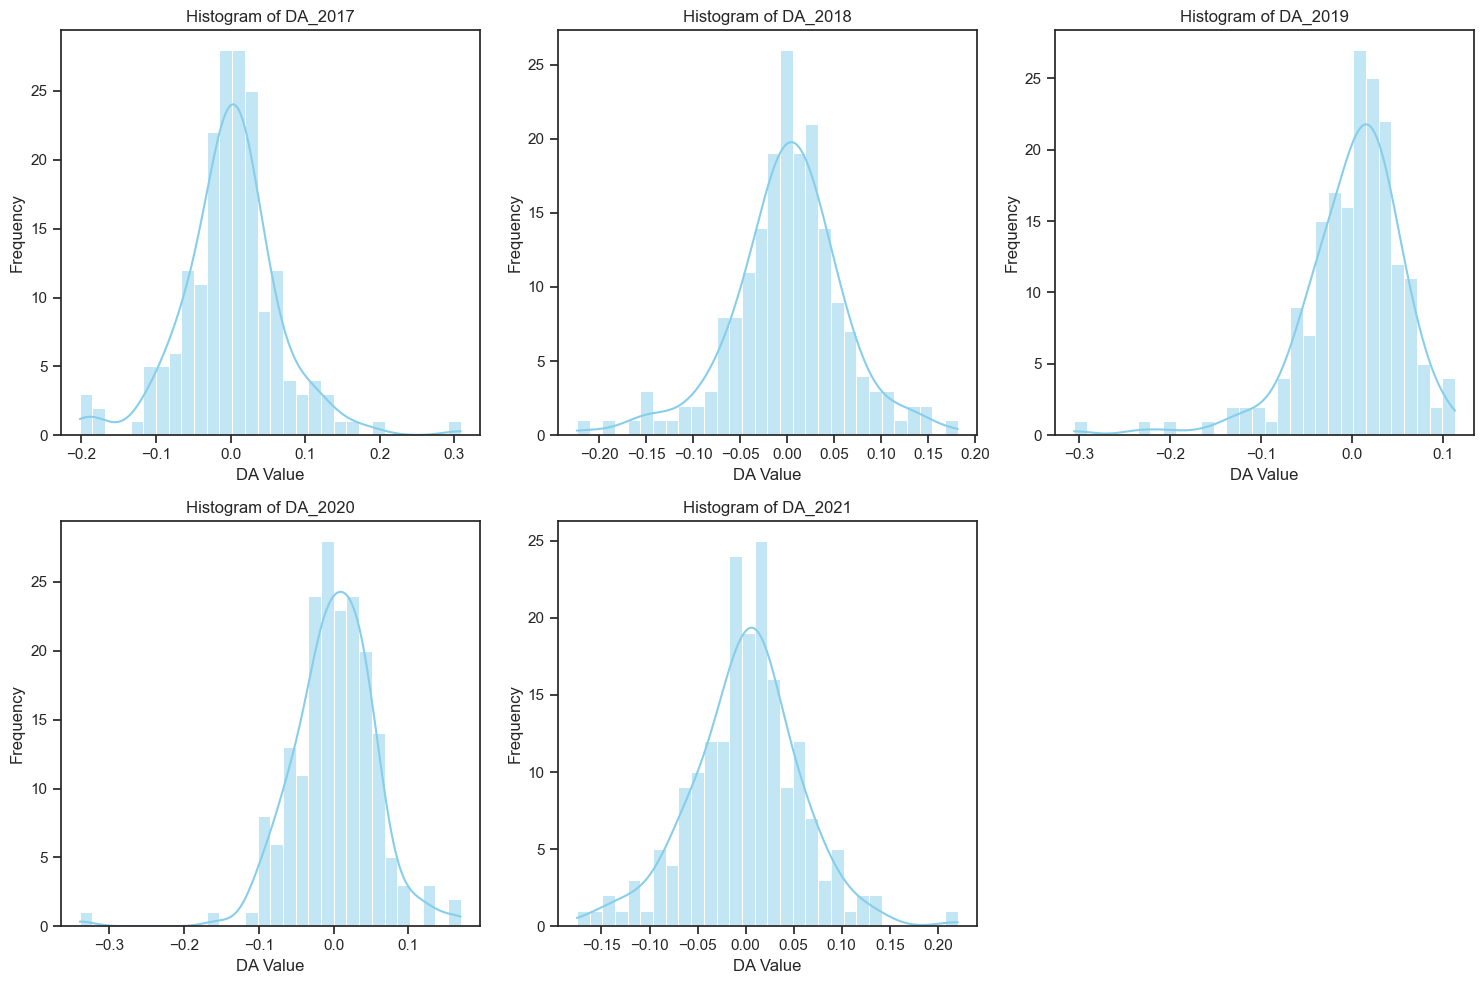

In [120]:
#Histogram of DA
da_columns = ['DA_2017', 'DA_2018', 'DA_2019', 'DA_2020','DA_2021']
plt.figure(figsize=(15, 10))

for i, col in enumerate(da_columns, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns of subplots
    sns.histplot(final_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel('DA Value')
    plt.ylabel('Frequency')

plt.tight_layout()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'DA_2017'),
  Text(1, 0, 'DA_2018'),
  Text(2, 0, 'DA_2019'),
  Text(3, 0, 'DA_2020'),
  Text(4, 0, 'DA_2021')])

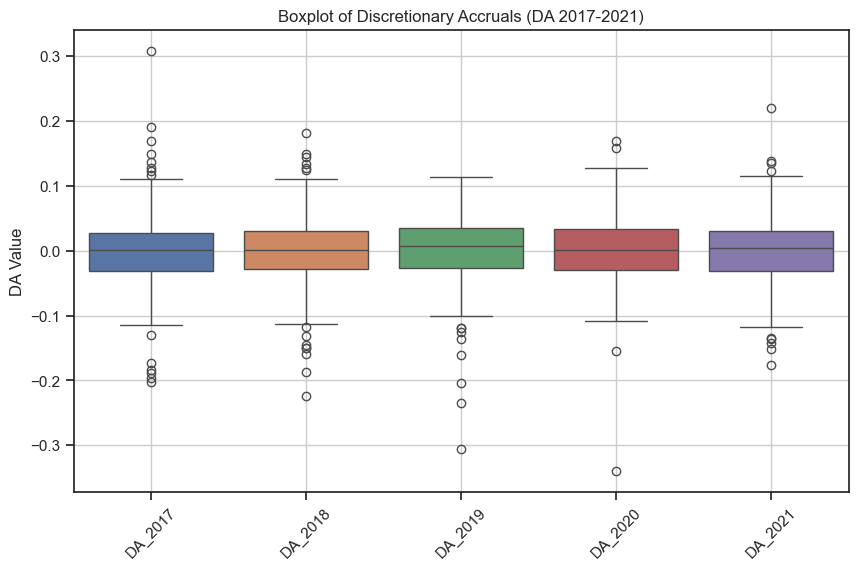

In [33]:
#boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df[da_columns])
plt.title('Boxplot of Discretionary Accruals (DA 2017-2021)')
plt.ylabel('DA Value')
plt.grid(True)
plt.xticks(rotation=45)

In [121]:
#function for classifying EM with DA value
def classify_em_global(df, da_columns, lower_q=0.25, upper_q=0.75):
    all_da_values = pd.concat([df[col] for col in da_columns], ignore_index=True)
    q_low = all_da_values.quantile(lower_q)
    q_high = all_da_values.quantile(upper_q)

    # Step 2: Classify each column based on global thresholds
    for col in da_columns:
        df[f'{col}_Classification'] = np.select(
            [
                df[col] < q_low,   # Downward manipulation
                df[col] > q_high   # Upward manipulation
            ],
            [1, 2],               # 1 = downward EM, 2 = upward EM
            default=0             # 0 = normal
        )

    return df

In [122]:
da_columns = ['DA_2017', 'DA_2018', 'DA_2019', 'DA_2020', 'DA_2021']
final_df = classify_em_global(final_df, da_columns, lower_q=0.25, upper_q=0.75)

In [123]:
final_df.rename(columns={
    'DA_2017_Classification': 'EM_2017',
    'DA_2018_Classification': 'EM_2018',
    'DA_2019_Classification': 'EM_2019',
    'DA_2020_Classification': 'EM_2020',
    'DA_2021_Classification': 'EM_2021',
}, inplace=True)

final_df.head()

,Company Name,REV_2016,REV_2017,REV_2018,REV_2019,REV_2020,REV_2021,NI_2016,NI_2017,NI_2018,...,DA_2019,NDAC_2020,DA_2020,NDAC_2021,DA_2021,EM_2017,EM_2018,EM_2019,EM_2020,EM_2021
1,7-Eleven Malaysia Holdings Berhad,469.0,537.8,536.1,576.6,631.8,674.1,11.60,12.30,12.40,...,-0.235127,-0.059381,-0.088589,-0.027851,-0.075740,0,0,1,1,1
12,Advancecon Holdings Berhad,52.3,65.4,66.0,73.8,62.3,65.0,5.90,4.54,2.57,...,0.045844,-0.032561,-0.011664,-0.020884,-0.033480,0,0,2,0,1
16,Aeon Co. Bhd.,900.6,1014.0,1052.7,1108.4,1008.1,871.3,17.80,25.80,25.40,...,-0.037464,-0.051402,-0.003906,-0.036895,-0.060190,0,1,1,0,1
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.10,46.90,14.40,...,-0.006013,-0.044258,0.032210,-0.031530,0.059779,2,0,0,0,2
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,...,0.017711,-0.032039,-0.031659,-0.018837,0.022074,0,0,0,1,0


In [124]:
#Identify company with consecutive negative/positive EM
em_col = ['EM_2017', 'EM_2018', 'EM_2019', 'EM_2020', 'EM_2021']
em_values = final_df[em_col]

#Create a boolean series for 1(downward) and 2(upward) EM consecutive years
consec_1 = (
    (em_values['EM_2017'] == 1) & (em_values['EM_2018'] == 1) |
    (em_values['EM_2018'] == 1) & (em_values['EM_2019'] == 1) |
    (em_values['EM_2019'] == 1) & (em_values['EM_2020'] == 1) |
    (em_values['EM_2020'] == 1) & (em_values['EM_2021'] == 1)
)

consec_2 = (
    (em_values['EM_2017'] == 2) & (em_values['EM_2018'] == 2) |
    (em_values['EM_2018'] == 2) & (em_values['EM_2019'] == 2) |
    (em_values['EM_2019'] == 2) & (em_values['EM_2020'] == 2) |
    (em_values['EM_2020'] == 2) & (em_values['EM_2021'] == 2)
)

# Filter only rows with consecutive EM years
rows_with_consecutive_em = final_df[consec_1 | consec_2]

In [109]:
print("Number of firms with consecutive EM:", rows_with_consecutive_em.shape[0])

Number of firms with consecutive EM: 94


In [43]:
#Export Company Name with consecutive EM
rows_with_consecutive_em[['Company Name']].to_excel('consecutive_em_companies.xlsx', index=False)

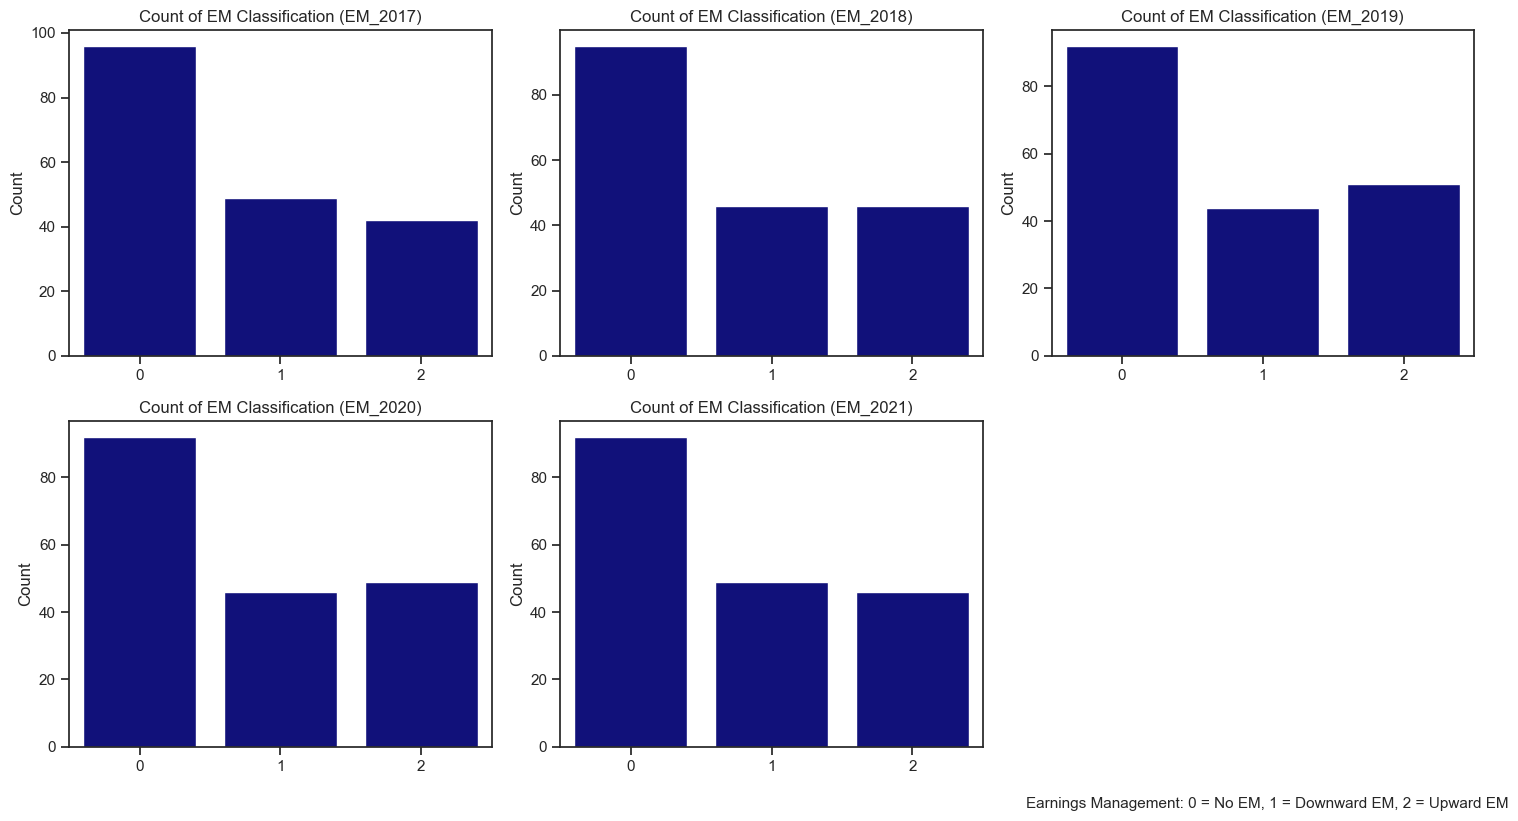

In [110]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(em_col, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=final_df, x=col, color='darkblue')
    plt.title(f'Count of EM Classification ({col})')
    plt.xlabel('')
    plt.ylabel('Count')

# Add global explanation
plt.figtext(
    0.85, -0.02,
    'Earnings Management: 0 = No EM, 1 = Downward EM, 2 = Upward EM',
    ha='center',
    fontsize=11
)

plt.tight_layout()

In [125]:
#Transform data to stack company_year
# Define target years
years = [2017, 2018, 2019, 2020, 2021]

# Financial features to include
features = ['REV', 'NI', 'OCF', 'TA', 'AR', 'PPE']

# Store each year's reshaped data
yearly_rows = []

for year in years:
    temp = pd.DataFrame()
    temp['Company Name'] = final_df['Company Name']
    temp['Primary Sector'] = final_df['Primary Sector']
    temp['Year'] = year
    
    # Assign EM with year-specific column name
    temp[f'EM_{year}'] = final_df[f'EM_{year}']
    
    for feature in features:
        prev_col = f'{feature}_{year - 1}'
        curr_col = f'{feature}_{year}'
        
        if prev_col in final_df.columns:
            temp[prev_col] = final_df[prev_col]
        if curr_col in final_df.columns:
            temp[curr_col] = final_df[curr_col]
    
    yearly_rows.append(temp)

unpivot_df = pd.concat(yearly_rows, ignore_index=True)
unpivot_df['Company_Year'] = unpivot_df['Company Name'] + '_' + unpivot_df['Year'].astype(str)

unpivot_df

,Company Name,Primary Sector,Year,EM_2017,REV_2016,REV_2017,NI_2016,NI_2017,OCF_2016,OCF_2017,...,AR_2020,PPE_2020,EM_2021,REV_2021,NI_2021,OCF_2021,TA_2021,AR_2021,PPE_2021,Company_Year
0,7-Eleven Malaysia Holdings Berhad,Consumer Staples,2017,0.0,469.0,537.8,11.60,12.30,16.30,12.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7-Eleven Malaysia Holdings Berhad_2017
1,Advancecon Holdings Berhad,Industrials,2017,0.0,52.3,65.4,5.90,4.54,5.19,5.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Advancecon Holdings Berhad_2017
2,Aeon Co. Bhd.,Consumer Staples,2017,0.0,900.6,1014.0,17.80,25.80,103.80,94.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aeon Co. Bhd._2017
3,Ajinomoto Berhad,Consumer Staples,2017,2.0,92.6,107.3,10.10,46.90,8.46,21.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ajinomoto Berhad_2017
4,Ajiya Berhad,Industrials,2017,0.0,88.5,90.7,3.24,3.34,7.71,4.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ajiya Berhad_2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
930,Westports Holdings Berhad,Industrials,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,65.70,418.30,1.0,485.3,194.00,264.20,1299.7,58.40,430.6,Westports Holdings Berhad_2021
931,Willowglen MSC Berhad,Information Technology,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.50,3.97,0.0,41.1,3.66,2.48,51.3,21.90,3.3,Willowglen MSC Berhad_2021
932,Y.S.P. Southeast Asia Holding Berhad,Health Care,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.60,35.40,1.0,67.6,3.64,15.30,107.5,13.70,32.6,Y.S.P. Southeast Asia Holding Berhad_2021
933,Yoong Onn Corporation Berhad,Consumer Discretionary,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.54,15.70,0.0,44.5,5.45,7.35,69.9,10.20,14.0,Yoong Onn Corporation Berhad_2021


In [126]:
#Transform data to stack company_year
features = ['REV', 'NI', 'OCF', 'TA', 'AR', 'PPE', 'EM']

data_by_year = {}

for year in years:
    keep_cols = ['Company_Year', 'Primary Sector']
    rename_map = {}

    for feat in features:
        if feat == 'EM':
            em_col = f'{feat}_{year}'
            if em_col in unpivot_df.columns:
                keep_cols.append(em_col)
                rename_map[em_col] = 'EM'
        else:
            prev_col = f'{feat}_{year-1}'
            curr_col = f'{feat}_{year}'
            if prev_col in unpivot_df.columns:
                keep_cols.append(prev_col)
                rename_map[prev_col] = f'{feat}_t-1'
            if curr_col in unpivot_df.columns:
                keep_cols.append(curr_col)
                rename_map[curr_col] = f'{feat}_t'

    df_year = unpivot_df[unpivot_df['Year'] == year][keep_cols]
    df_year = df_year.rename(columns=rename_map)

    data_by_year[year] = df_year.reset_index(drop=True)

In [127]:
# Merge all yearly DataFrames into one
final_df = pd.concat(data_by_year.values(), ignore_index=True)

print(final_df.shape)
final_df.head()

(935, 15)


,Company_Year,Primary Sector,REV_t-1,REV_t,NI_t-1,NI_t,OCF_t-1,OCF_t,TA_t-1,TA_t,AR_t-1,AR_t,PPE_t-1,PPE_t,EM
0,7-Eleven Malaysia Holdings Berhad_2017,Consumer Staples,469.0,537.8,11.60,12.30,16.30,12.10,172.5,195.5,1.06,1.37,71.1,86.2,0.0
1,Advancecon Holdings Berhad_2017,Industrials,52.3,65.4,5.90,4.54,5.19,5.00,66.0,90.7,27.40,30.30,30.4,45.3,0.0
2,Aeon Co. Bhd._2017,Consumer Staples,900.6,1014.0,17.80,25.80,103.80,94.70,985.1,1084.4,11.70,18.70,771.7,861.7,0.0
3,Ajinomoto Berhad_2017,Consumer Staples,92.6,107.3,10.10,46.90,8.46,21.10,85.4,117.6,9.89,9.45,18.5,21.3,2.0
4,Ajiya Berhad_2017,Industrials,88.5,90.7,3.24,3.34,7.71,4.59,104.3,114.5,26.40,27.00,40.8,42.8,0.0


### Correlation Analysis (Firm Profitability and Size with EM)

In [128]:
profit_cols = ['NI_t-1', 'NI_t', 'OCF_t-1', 'OCF_t', 'TA_t-1', 'TA_t']
cols = ['EM'] + profit_cols

# Keep only rows where EM is 1 or 2
filtered_df = final_df[final_df['EM'].isin([1, 2])][cols]

# Create binary targets
filtered_df['EM_is_1'] = (filtered_df['EM'] == 1).astype(int)
filtered_df['EM_is_2'] = (filtered_df['EM'] == 2).astype(int)

# Correlation map with EM = 1
corr_em1 = filtered_df[profit_cols + ['EM_is_1']].corr()['EM_is_1'].drop('EM_is_1')

# Correlation map with EM = 2
corr_em2 = filtered_df[profit_cols + ['EM_is_2']].corr()['EM_is_2'].drop('EM_is_2')

#Correlation Table
correlation_table = pd.DataFrame({
    'Correlation with EM = 1': corr_em1,
    'Correlation with EM = 2': corr_em2
})

print("\nCorrelation Between Profitability Features and EM (Downward and Upward):\n")
display(correlation_table.round(3))


Correlation Between Profitability Features and EM (Downward and Upward):



,Correlation with EM = 1,Correlation with EM = 2
NI_t-1,0.080,-0.080
NI_t,0.054,-0.054
OCF_t-1,0.164,-0.164
OCF_t,0.275,-0.275
TA_t-1,0.070,-0.070
TA_t,0.058,-0.058


# split dataset to train and test set

In [63]:
#split with even distribution of EM class
model_df=final_df.copy()
trainset=model_df.groupby('EM',group_keys=False).apply(lambda x: x.sample(frac=0.7, random_state=42))
testset=model_df.drop(index=trainset.index)

C:\Users\hp\AppData\Local\Temp\ipykernel_28456\2364581966.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trainset=model_df.groupby('EM',group_keys=False).apply(lambda x: x.sample(frac=0.7, random_state=42))


In [65]:
testset['EM'].value_counts()

EM
0.0    140
2.0     70
1.0     70
Name: count, dtype: int64

In [66]:
drop_col=['EM', 'Company_Year', 'Primary Sector']
X_train=trainset.drop(columns=drop_col)
y_train=trainset['EM'].astype(int)

X_test=testset.drop(columns=drop_col)
y_test=testset['EM'].astype(int)

Decision Tree Classifier

In [67]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_y_pred = dt_model.predict(X_test)

In [68]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_test, y_pred, class_labels=[0, 1, 2], class_names=None, zero_division=1):
    if class_names is None:
        class_names = [f'Class {i}' for i in class_labels]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    print("=== Confusion Matrix ===")
    print(cm)

    # TP, FP, FN, TN per class
    print("\n=== TP, FP, FN, TN Per Class ===")
    for i, label in enumerate(class_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        print(f"\n{class_names[i]} ({label}):")
        print(f"  TP: {TP}")
        print(f"  FP: {FP}")
        print(f"  FN: {FN}")
        print(f"  TN: {TN}")

    # Classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred, labels=class_labels,
                                target_names=class_names, zero_division=zero_division))

    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None, labels=class_labels, zero_division=zero_division)
    recall_per_class = recall_score(y_test, y_pred, average=None, labels=class_labels, zero_division=zero_division)
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=class_labels, zero_division=zero_division)

    print("=== Per-Class Metrics ===")
    for i, cls in enumerate(class_names):
        print(f"{cls}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall   : {recall_per_class[i]:.4f}")
        print(f"  F1-score : {f1_per_class[i]:.4f}")

    # Overall & Micro-Averaged Metrics
    print("\n=== Overall Metrics ===")
    print(f"Accuracy                : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (weighted)    : {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall (weighted)       : {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-score (weighted)     : {f1_score(y_test, y_pred, average='weighted'):.4f}")

In [69]:
evaluate_model(y_test, dt_y_pred)

=== Confusion Matrix ===
[[108  14  18]
 [ 23  42   5]
 [ 21   2  47]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 108
  FP: 44
  FN: 32
  TN: 96

Class 1 (1):
  TP: 42
  FP: 16
  FN: 28
  TN: 194

Class 2 (2):
  TP: 47
  FP: 23
  FN: 23
  TN: 187

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.71      0.77      0.74       140
     Class 1       0.72      0.60      0.66        70
     Class 2       0.67      0.67      0.67        70

    accuracy                           0.70       280
   macro avg       0.70      0.68      0.69       280
weighted avg       0.70      0.70      0.70       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.7105
  Recall   : 0.7714
  F1-score : 0.7397
Class 1:
  Precision: 0.7241
  Recall   : 0.6000
  F1-score : 0.6562
Class 2:
  Precision: 0.6714
  Recall   : 0.6714
  F1-score : 0.6714

=== Overall Metrics ===
Accuracy                : 0.7036
Precision (weighted)    : 0.7042
Recall

### Hyperparameter Tuning

In [70]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

dt = DecisionTreeClassifier()
dt_param_dist = {
    'max_depth': randint(2, 6),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}
dt_random = RandomizedSearchCV(dt, dt_param_dist, n_iter=10, cv=5, 
                               random_state=42, scoring='f1_weighted')
dt_random.fit(X_train, y_train)
dt_best_model = dt_random.best_estimator_

print("Decision Tree best params:", dt_random.best_params_)

Decision Tree best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 4}


In [71]:
dt_y_pred2 = dt_best_model.predict(X_test)

In [72]:
evaluate_model(y_test, dt_y_pred2)

=== Confusion Matrix ===
[[110  11  19]
 [ 46  24   0]
 [ 35   3  32]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 110
  FP: 81
  FN: 30
  TN: 59

Class 1 (1):
  TP: 24
  FP: 14
  FN: 46
  TN: 196

Class 2 (2):
  TP: 32
  FP: 19
  FN: 38
  TN: 191

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.58      0.79      0.66       140
     Class 1       0.63      0.34      0.44        70
     Class 2       0.63      0.46      0.53        70

    accuracy                           0.59       280
   macro avg       0.61      0.53      0.55       280
weighted avg       0.60      0.59      0.58       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.5759
  Recall   : 0.7857
  F1-score : 0.6647
Class 1:
  Precision: 0.6316
  Recall   : 0.3429
  F1-score : 0.4444
Class 2:
  Precision: 0.6275
  Recall   : 0.4571
  F1-score : 0.5289

=== Overall Metrics ===
Accuracy                : 0.5929
Precision (weighted)    : 0.6027
Recall

Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

In [74]:
evaluate_model(y_test,rf_y_pred)

=== Confusion Matrix ===
[[117   8  15]
 [ 32  36   2]
 [ 38   2  30]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 117
  FP: 70
  FN: 23
  TN: 70

Class 1 (1):
  TP: 36
  FP: 10
  FN: 34
  TN: 200

Class 2 (2):
  TP: 30
  FP: 17
  FN: 40
  TN: 193

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.63      0.84      0.72       140
     Class 1       0.78      0.51      0.62        70
     Class 2       0.64      0.43      0.51        70

    accuracy                           0.65       280
   macro avg       0.68      0.59      0.62       280
weighted avg       0.67      0.65      0.64       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.6257
  Recall   : 0.8357
  F1-score : 0.7156
Class 1:
  Precision: 0.7826
  Recall   : 0.5143
  F1-score : 0.6207
Class 2:
  Precision: 0.6383
  Recall   : 0.4286
  F1-score : 0.5128

=== Overall Metrics ===
Accuracy                : 0.6536
Precision (weighted)    : 0.6681
Recall

### Hyperparameter Tuning

In [75]:
rf = RandomForestClassifier()
rf_param_dist = {
    'n_estimators': randint(50, 150),
    'max_depth': randint(2, 6),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}
rf_random = RandomizedSearchCV(rf, rf_param_dist, n_iter=10, cv=5,
                               random_state=42, scoring='f1_weighted')
rf_random.fit(X_train, y_train)
rf_best_model = rf_random.best_estimator_

print("Random Forest best params:", rf_random.best_params_)

Random Forest best params: {'bootstrap': False, 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 4, 'n_estimators': 100}


In [76]:
rf_y_pred2 = rf_best_model.predict(X_test)
evaluate_model(y_test,rf_y_pred2)

=== Confusion Matrix ===
[[133   5   2]
 [ 51  19   0]
 [ 52   4  14]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 133
  FP: 103
  FN: 7
  TN: 37

Class 1 (1):
  TP: 19
  FP: 9
  FN: 51
  TN: 201

Class 2 (2):
  TP: 14
  FP: 2
  FN: 56
  TN: 208

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.56      0.95      0.71       140
     Class 1       0.68      0.27      0.39        70
     Class 2       0.88      0.20      0.33        70

    accuracy                           0.59       280
   macro avg       0.71      0.47      0.47       280
weighted avg       0.67      0.59      0.53       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.5636
  Recall   : 0.9500
  F1-score : 0.7074
Class 1:
  Precision: 0.6786
  Recall   : 0.2714
  F1-score : 0.3878
Class 2:
  Precision: 0.8750
  Recall   : 0.2000
  F1-score : 0.3256

=== Overall Metrics ===
Accuracy                : 0.5929
Precision (weighted)    : 0.6702
Recall (

XGBoost

In [79]:
import xgboost as xgb
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_y_pred = xgb_model.predict(X_test)

In [80]:
evaluate_model(y_test,xgb_y_pred)

=== Confusion Matrix ===
[[123   7  10]
 [ 19  51   0]
 [ 19   2  49]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 123
  FP: 38
  FN: 17
  TN: 102

Class 1 (1):
  TP: 51
  FP: 9
  FN: 19
  TN: 201

Class 2 (2):
  TP: 49
  FP: 10
  FN: 21
  TN: 200

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.76      0.88      0.82       140
     Class 1       0.85      0.73      0.78        70
     Class 2       0.83      0.70      0.76        70

    accuracy                           0.80       280
   macro avg       0.81      0.77      0.79       280
weighted avg       0.80      0.80      0.79       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.7640
  Recall   : 0.8786
  F1-score : 0.8173
Class 1:
  Precision: 0.8500
  Recall   : 0.7286
  F1-score : 0.7846
Class 2:
  Precision: 0.8305
  Recall   : 0.7000
  F1-score : 0.7597

=== Overall Metrics ===
Accuracy                : 0.7964
Precision (weighted)    : 0.8021
Recall

### Hyperparamter Tuning

In [ ]:
from sklearn.model_selection import StratifiedKFold
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

# Hyperparameter distribution
xgb_param_dist = {
    'n_estimators': randint(50, 150),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 5),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random search
xgb_random = RandomizedSearchCV(
    xgb, param_distributions=xgb_param_dist, n_iter=10, cv=cv,scoring='f1_weighted',
    random_state=42,n_jobs=-1,verbose=1
)
xgb_random.fit(X_train, y_train)
xgb_best_model = xgb_random.best_estimator_

# Output best params
print("XGBoost best params:", xgb_random.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
XGBoost best params: {'colsample_bytree': np.float64(0.9818496824692566), 'learning_rate': np.float64(0.18896547008552977), 'max_depth': 3, 'n_estimators': 144, 'reg_alpha': np.float64(0.9218742350231168), 'reg_lambda': np.float64(0.0884925020519195), 'subsample': np.float64(0.7587948587257435)}


In [82]:
xgb_y_pred2 = xgb_best_model.predict(X_test)
evaluate_model(y_test,xgb_y_pred2)

=== Confusion Matrix ===
[[126   7   7]
 [ 22  48   0]
 [ 19   3  48]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 126
  FP: 41
  FN: 14
  TN: 99

Class 1 (1):
  TP: 48
  FP: 10
  FN: 22
  TN: 200

Class 2 (2):
  TP: 48
  FP: 7
  FN: 22
  TN: 203

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.75      0.90      0.82       140
     Class 1       0.83      0.69      0.75        70
     Class 2       0.87      0.69      0.77        70

    accuracy                           0.79       280
   macro avg       0.82      0.76      0.78       280
weighted avg       0.80      0.79      0.79       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.7545
  Recall   : 0.9000
  F1-score : 0.8208
Class 1:
  Precision: 0.8276
  Recall   : 0.6857
  F1-score : 0.7500
Class 2:
  Precision: 0.8727
  Recall   : 0.6857
  F1-score : 0.7680

=== Overall Metrics ===
Accuracy                : 0.7929
Precision (weighted)    : 0.8023
Recall 

Gradient Boost

In [83]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

gb_y_pred = gb_model.predict(X_test)

In [84]:
evaluate_model(y_test, gb_y_pred)

=== Confusion Matrix ===
[[124   9   7]
 [ 29  41   0]
 [ 28   1  41]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 124
  FP: 57
  FN: 16
  TN: 83

Class 1 (1):
  TP: 41
  FP: 10
  FN: 29
  TN: 200

Class 2 (2):
  TP: 41
  FP: 7
  FN: 29
  TN: 203

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.69      0.89      0.77       140
     Class 1       0.80      0.59      0.68        70
     Class 2       0.85      0.59      0.69        70

    accuracy                           0.74       280
   macro avg       0.78      0.69      0.72       280
weighted avg       0.76      0.74      0.73       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.6851
  Recall   : 0.8857
  F1-score : 0.7726
Class 1:
  Precision: 0.8039
  Recall   : 0.5857
  F1-score : 0.6777
Class 2:
  Precision: 0.8542
  Recall   : 0.5857
  F1-score : 0.6949

=== Overall Metrics ===
Accuracy                : 0.7357
Precision (weighted)    : 0.7571
Recall 

### Hyperparamter Tuning

In [85]:
gb = GradientBoostingClassifier()
gb_param_dist = {
    'n_estimators': randint(50, 150),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 5),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10)
}
gb_random = RandomizedSearchCV(gb, gb_param_dist, n_iter=10, cv=5, 
                               random_state=42, scoring='f1_weighted')
gb_random.fit(X_train, y_train)

gb_random.fit(X_train, y_train)
gb_best_model = gb_random.best_estimator_

print("Gradient Boost best params:", gb_random.best_params_)

Gradient Boost best params: {'learning_rate': np.float64(0.20664617716135766), 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 100}


In [86]:
gb_y_pred2 = gb_best_model.predict(X_test)
evaluate_model(y_test,gb_y_pred2)

=== Confusion Matrix ===
[[121  11   8]
 [ 26  44   0]
 [ 23   2  45]]

=== TP, FP, FN, TN Per Class ===

Class 0 (0):
  TP: 121
  FP: 49
  FN: 19
  TN: 91

Class 1 (1):
  TP: 44
  FP: 13
  FN: 26
  TN: 197

Class 2 (2):
  TP: 45
  FP: 8
  FN: 25
  TN: 202

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.71      0.86      0.78       140
     Class 1       0.77      0.63      0.69        70
     Class 2       0.85      0.64      0.73        70

    accuracy                           0.75       280
   macro avg       0.78      0.71      0.74       280
weighted avg       0.76      0.75      0.75       280

=== Per-Class Metrics ===
Class 0:
  Precision: 0.7118
  Recall   : 0.8643
  F1-score : 0.7806
Class 1:
  Precision: 0.7719
  Recall   : 0.6286
  F1-score : 0.6929
Class 2:
  Precision: 0.8491
  Recall   : 0.6429
  F1-score : 0.7317

=== Overall Metrics ===
Accuracy                : 0.7500
Precision (weighted)    : 0.7611
Recall 

Visualize Output

In [88]:
pred_df_visualize = pd.DataFrame({
    'DT (default)': dt_y_pred,
    'DT (tuned)': dt_y_pred2,
    'RF (default)': rf_y_pred,
    'RF (tuned)': rf_y_pred2,
    'GB (default)': gb_y_pred,
    'GB (tuned)': gb_y_pred2,
    'XGB (default)': xgb_y_pred,
    'XGB (tuned)': xgb_y_pred2,
})

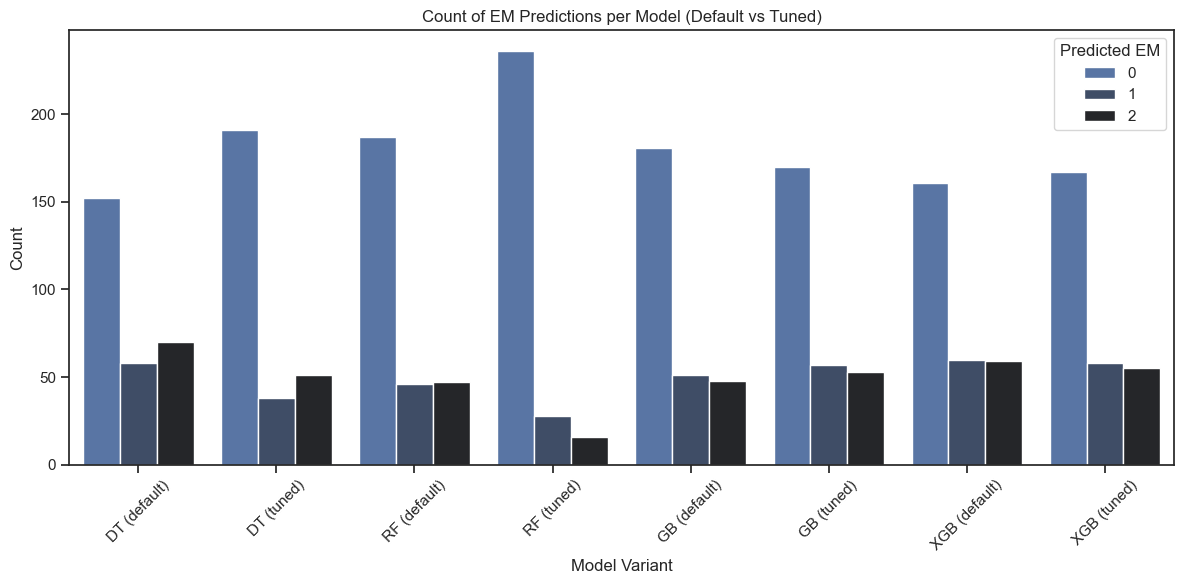

In [92]:
pred_melted = pred_df_visualize.melt(var_name='Model', value_name='Predicted_EM')

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=pred_melted, x='Model', hue='Predicted_EM', palette='dark:b_r')

# Add labels and title
plt.title("Count of EM Predictions per Model (Default vs Tuned)")
plt.xlabel("Model Variant")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Predicted EM')

plt.tight_layout()

In [98]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-Score": f1_score(y_true, y_pred, average='weighted')
    }

results = {}

for col in pred_df_visualize.columns:
    results[col] = get_metrics(y_test, pred_df_visualize[col])

metrics_df = pd.DataFrame(results).T

metrics_df['Ranking'] = metrics_df['F1-Score'].rank(ascending=False).astype(int)
metrics_df = metrics_df.sort_values('F1-Score', ascending=False).round(4)

metrics_df

,Accuracy,Precision,Recall,F1-Score,Ranking
XGB (default),0.7964,0.8021,0.7964,0.7947,1
XGB (tuned),0.7929,0.8023,0.7929,0.7899,2
GB (tuned),0.7500,0.7611,0.7500,0.7465,3
GB (default),0.7357,0.7571,0.7357,0.7294,4
DT (default),0.7036,0.7042,0.7036,0.7018,5
RF (default),0.6536,0.6681,0.6536,0.6412,6
DT (tuned),0.5929,0.6027,0.5929,0.5757,7
RF (tuned),0.5929,0.6702,0.5929,0.5321,8


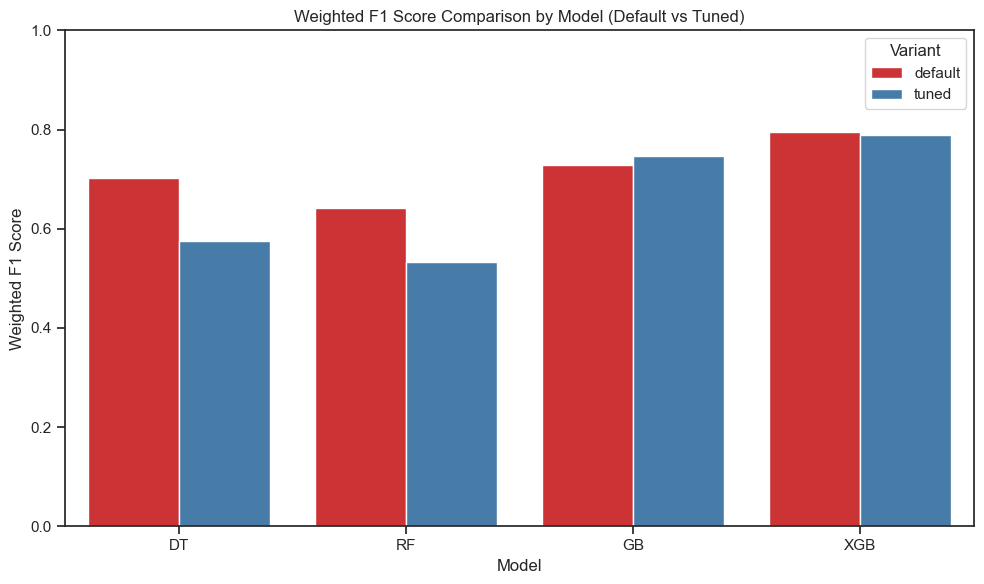

In [91]:
f1_scores = {
    'DT (default)': f1_score(testset['EM'], dt_y_pred, average='weighted'),
    'DT (tuned)': f1_score(testset['EM'], dt_y_pred2, average='weighted'),
    'RF (default)': f1_score(testset['EM'], rf_y_pred, average='weighted'),
    'RF (tuned)': f1_score(testset['EM'], rf_y_pred2, average='weighted'),
    'GB (default)': f1_score(testset['EM'], gb_y_pred, average='weighted'),
    'GB (tuned)': f1_score(testset['EM'], gb_y_pred2, average='weighted'),
    'XGB (default)': f1_score(testset['EM'], xgb_y_pred, average='weighted'),
    'XGB (tuned)': f1_score(testset['EM'], xgb_y_pred2, average='weighted'),
}

# Convert to DataFrame
f1_df = pd.DataFrame(list(f1_scores.items()), columns=['Model', 'F1_Weighted'])

# Separate model type and variant
f1_df[['Model_Type', 'Variant']] = f1_df['Model'].str.extract(r'(\w+)\s+\((\w+)\)')

# Plot side-by-side barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=f1_df, x='Model_Type', y='F1_Weighted', hue='Variant', palette='Set1')

# Customize
plt.title('Weighted F1 Score Comparison by Model (Default vs Tuned)')
plt.ylabel('Weighted F1 Score')
plt.ylim(0, 1)
plt.xlabel('Model')
plt.legend(title='Variant')
plt.tight_layout()